# MIT 805 Part 1 - Amazon Reviews 2023

**Dataset:** Clothing, Shoes and Jewelry reviews from McAuley Lab's Amazon Reviews 2023 dataset.  
**Purpose:** Assess data quality, perform exploratory analysis, and generate dataset-specific evidence for the 7 Vs of Big Data.



In [ ]:
!pip -q install pyspark==4.0.0 huggingface-hub matplotlib seaborn

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, os, platform

from huggingface_hub import HfApi, hf_hub_download
from pyspark.sql import SparkSession, functions as F, types as T
import matplotlib.pyplot as plt
import seaborn as sns

spark = (SparkSession.builder
         .appName("MIT805-Part1-AmazonReviews")
         .config("spark.sql.shuffle.partitions", "64")
         .config("spark.driver.memory", "10g")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

ROOT = Path("/content/mit805_part1")
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "output"
FIGURE_DIR = ROOT / "figures"
for folder in (RAW_DIR, PROCESSED_DIR, OUTPUT_DIR, FIGURE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print("Run time (UTC):", datetime.now(timezone.utc).isoformat())
print("Python:", platform.python_version())
print("Spark:", spark.version)
print("Storage:", ROOT)


Run time (UTC): 2026-09-02T22:01:54.210463+00:00
Python: 3.13.15
Spark: 4.0.0
Storage: /content/mit805_part1


## Provenance, terms, and scale

- **Publisher:** McAuley Lab, University of California San Diego.
- **Repository:** https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023
- **Paper:** Hou et al. (2024), *Bridging Language and Items for Retrieval and Recommendation*, https://arxiv.org/abs/2403.03952
- **Period represented:** May 1996 to September 2023 (dataset-level description).
- **Terms:** the maintainers state that the dataset is made available primarily for research, but they do not assign a standalone licence. Use is therefore limited here to non-commercial academic analysis, with attribution and ethical safeguards. See https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/discussions/1
- **Privacy/ethics:** reviewer identifiers are pseudonymous but still potentially linkable. Do not attempt re-identification, publish review-level extracts, or redistribute the raw file.

The selected raw review file is listed as **27.8 GB**. The notebook verifies the hosted byte count and the downloaded byte count rather than relying only on the display label.


## Dataset-size compliance and processing path

The project uses three explicitly measured dataset stages. **GB values use decimal units (bytes / 1,000,000,000); GiB values use binary units (bytes / 1,073,741,824).**

| Dataset stage | Definition in this project | Exact measured size | Requirement | Result |
|---|---|---:|---:|---|
| **Raw dataset** | Original publicly available McAuley Lab Amazon Reviews 2023 Clothing, Shoes and Jewelry JSONL file hosted on Hugging Face | 27,810,080,533 bytes = **27.810 GB** | 25–40 GB | **Met** |
| **Working dataset** | Complete hosted file downloaded into the Colab workspace without reducing it | 27,810,080,533 bytes = **27.810 GB** (25.900 GiB) | At least 12 GB | **Met** |
| **Processing dataset** | Line-safe portion actually loaded and analysed by PySpark | 3,221,225,482 bytes = **3.221 GB** (3.000 GiB) | At least 3 GB | **Met** |

### How the three stages are produced and verified

1. The Hugging Face API reports the size of the original hosted file. The notebook asserts that this **raw dataset** is between 25 GB and 40 GB.
2. The hf_hub_download() function downloads the complete file to RAW_PATH. Its size is measured from local storage and checked against the 12 GB minimum. Because the complete public file is downloaded, the raw and working sizes are identical; they are different pipeline stages, not necessarily different files.
3. The notebook reads the working JSONL file one complete line at a time and copies records until at least 3 * 1024**3 bytes have been written. Each JSONL line is one review, so this prevents the final record from being cut in half. The result exceeds the threshold slightly because the last complete line is retained.
4. PySpark loads **that exact processing file**, not merely its metadata, using spark.read.json(str(PROCESSING_PATH)). The load produced **7,231,543 review records** and the prepared DataFrame contains **14 columns**.
5. PySpark then casts ratings, helpful votes and timestamps; creates readable review times, review years, text lengths and title lengths; repartitions the DataFrame into 64 partitions; caches it; and performs the quality checks, aggregations and EDA shown below. Pandas is used only after Spark has reduced the millions of records to small aggregate tables for plotting.

**Processing limitation.** The 3 GiB processing file is a sequential, line-safe prefix rather than a random sample. It satisfies the processing-size criterion, but its product or temporal composition may differ from the full 27.810 GB category file.

In [ ]:
REPO_ID = "McAuley-Lab/Amazon-Reviews-2023"
HF_FILENAME = "raw/review_categories/Clothing_Shoes_and_Jewelry.jsonl"
DISPLAYED_RAW_SIZE_GB = 27.8
MIN_PROCESSING_BYTES = 3 * 1024**3  # 3 GiB, deliberately conservative

api = HfApi()
info = api.dataset_info(REPO_ID, files_metadata=True)
entry = next(s for s in info.siblings if s.rfilename == HF_FILENAME)
hosted_bytes = entry.size

scale = {
    "raw_dataset_definition": "Amazon Reviews 2023 - Clothing, Shoes and Jewelry raw reviews",
    "hosted_file_bytes": hosted_bytes,
    "hosted_file_GB_decimal": round(hosted_bytes / 1e9, 3),
    "displayed_source_size_GB": DISPLAYED_RAW_SIZE_GB,
    "retrieved_utc": datetime.now(timezone.utc).isoformat(),
}
print(json.dumps(scale, indent=2))
assert 25 <= hosted_bytes / 1e9 <= 40, "Selected raw file is outside the required 25-40 GB range"


{
  "raw_dataset_definition": "Amazon Reviews 2023 - Clothing, Shoes and Jewelry raw reviews",
  "hosted_file_bytes": 27810080533,
  "hosted_file_GB_decimal": 27.81,
  "displayed_source_size_GB": 27.8,
  "retrieved_utc": "2026-09-02T22:02:04.431848+00:00"
}


## Download and prepare the working and processing datasets

The full selected raw file is the working dataset. A line-safe prefix of at least 3 GiB is created for processing so that the final record is not truncated. If the file is already in Google Drive, change `RAW_PATH` to that location and skip the download.


In [ ]:
downloaded = hf_hub_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    filename=HF_FILENAME,
    local_dir=RAW_DIR,
)
RAW_PATH = Path(downloaded)
raw_bytes = RAW_PATH.stat().st_size
print(f"Working file: {RAW_PATH}")
print(f"Working size: {raw_bytes:,} bytes ({raw_bytes/1e9:.3f} GB; {raw_bytes/1024**3:.3f} GiB)")
assert raw_bytes >= 12e9, "Working dataset must be at least 12 GB"


raw/review_categories/Clothing_Shoes_and(…): reconstructing file:   0%|          |  0.00B / 27.8GB            

raw/review_categories/Clothing_Shoes_and(…): downloading bytes:           |  0.00B            

Working file: /content/mit805_part1/data/raw/raw/review_categories/Clothing_Shoes_and_Jewelry.jsonl
Working size: 27,810,080,533 bytes (27.810 GB; 25.900 GiB)


In [ ]:
PROCESSING_PATH = PROCESSED_DIR / "Clothing_Shoes_and_Jewelry_3GiB.jsonl"

if not PROCESSING_PATH.exists() or PROCESSING_PATH.stat().st_size < MIN_PROCESSING_BYTES:
    copied = 0
    with RAW_PATH.open("rb") as source, PROCESSING_PATH.open("wb") as target:
        while copied < MIN_PROCESSING_BYTES:
            line = source.readline()
            if not line:
                break
            target.write(line)
            copied += len(line)

processing_bytes = PROCESSING_PATH.stat().st_size
print(f"Processing size: {processing_bytes:,} bytes ({processing_bytes/1e9:.3f} GB; {processing_bytes/1024**3:.3f} GiB)")
assert processing_bytes >= MIN_PROCESSING_BYTES

scale.update({
    "working_file_bytes": raw_bytes,
    "working_file_GB_decimal": round(raw_bytes / 1e9, 3),
    "processing_file_bytes": processing_bytes,
    "processing_file_GB_decimal": round(processing_bytes / 1e9, 3),
})
(OUTPUT_DIR / "dataset_scale.json").write_text(json.dumps(scale, indent=2), encoding="utf-8")


Processing size: 3,221,225,482 bytes (3.221 GB; 3.000 GiB)


408

## Load with Spark and inspect structure

Amazon review records contain ratings, titles, review text, product and pseudonymous user identifiers, timestamps, helpful-vote counts, verification flags, and image references. Explicit casting below makes invalid values visible instead of silently accepting them.


In [ ]:
reviews_raw = spark.read.json(str(PROCESSING_PATH))
reviews_raw.printSchema()

reviews = (reviews_raw
    .withColumn("rating", F.col("rating").cast("double"))
    .withColumn("helpful_vote", F.col("helpful_vote").cast("long"))
    .withColumn("timestamp", F.col("timestamp").cast("long"))
    .withColumn("review_time", F.to_timestamp(F.from_unixtime(F.col("timestamp") / 1000)))
    .withColumn("review_year", F.year("review_time"))
    .withColumn("text_length", F.length(F.coalesce(F.col("text"), F.lit(""))))
    .withColumn("title_length", F.length(F.coalesce(F.col("title"), F.lit(""))))
    .repartition(64)
    .cache())

row_count = reviews.count()
column_count = len(reviews.columns)
print(f"Rows: {row_count:,}; columns: {column_count}")
reviews.show(5, truncate=80)


root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)

Rows: 7,231,543; columns: 14
+----------+------------+------+-----------+------+--------------------------------------------------------------------------------+-------------+----------------------------------------------------------------+----------------------------+-----------------+-------------------+-----------+-

## Data quality assessment

We test completeness, duplicates, valid rating ranges, timestamps, helpful-vote values, and unusually short/long text. A repeated `(user_id, parent_asin, timestamp, text)` tuple is treated as a potential duplicate, not automatically deleted: repeated reviews can also arise from merged or variant product listings.


In [ ]:
null_exprs = [
    F.sum(F.col(c).isNull().cast("long")).alias(c)
    for c in reviews.columns
]
null_counts = reviews.agg(*null_exprs)
null_counts.show(truncate=False)

quality = reviews.agg(
    F.count("*").alias("rows"),
    F.sum((~F.col("rating").between(1, 5) | F.col("rating").isNull()).cast("long")).alias("invalid_or_null_rating"),
    F.sum((F.col("helpful_vote") < 0).cast("long")).alias("negative_helpful_votes"),
    F.sum((F.col("text_length") == 0).cast("long")).alias("empty_review_text"),
    F.sum((F.col("text_length") > 10000).cast("long")).alias("text_over_10000_chars"),
    F.min("review_time").alias("earliest_review"),
    F.max("review_time").alias("latest_review"),
).first().asDict()

duplicate_rows = (reviews
    .groupBy("user_id", "parent_asin", "timestamp", "text")
    .count().filter(F.col("count") > 1)
    .agg(F.sum(F.col("count") - 1).alias("duplicate_rows"))
    .first()[0] or 0)
quality["potential_duplicate_rows"] = duplicate_rows
quality["potential_duplicate_pct"] = round(100 * duplicate_rows / row_count, 4)
print(json.dumps({k: str(v) for k, v in quality.items()}, indent=2))
(OUTPUT_DIR / "quality_summary.json").write_text(json.dumps({k: str(v) for k, v in quality.items()}, indent=2), encoding="utf-8")


+----+------------+------+-----------+------+----+---------+-----+-------+-----------------+-----------+-----------+-----------+------------+
|asin|helpful_vote|images|parent_asin|rating|text|timestamp|title|user_id|verified_purchase|review_time|review_year|text_length|title_length|
+----+------------+------+-----------+------+----+---------+-----+-------+-----------------+-----------+-----------+-----------+------------+
|0   |0           |0     |0          |0     |0   |0        |0    |0      |0                |0          |0          |0          |0           |
+----+------------+------+-----------+------+----+---------+-----+-------+-----------------+-----------+-----------+-----------+------------+

{
  "rows": "7231543",
  "invalid_or_null_rating": "0",
  "negative_helpful_votes": "0",
  "empty_review_text": "495",
  "text_over_10000_chars": "18",
  "earliest_review": "1999-12-01 01:41:03",
  "latest_review": "2023-03-25 20:39:13",
  "potential_duplicate_rows": "23544",
  "potential

316

## Exploratory data analysis

The following aggregations identify rating imbalance, temporal coverage, verified-purchase behaviour, helpfulness, review-length patterns, and heavily reviewed products. Only these compact results are converted to Pandas.


In [ ]:
numeric_summary = reviews.select("rating", "helpful_vote", "text_length").summary()
numeric_summary.show(truncate=False)

rating_counts = reviews.groupBy("rating").count().orderBy("rating")
yearly = (reviews.filter(F.col("review_year").isNotNull())
          .groupBy("review_year")
          .agg(F.count("*").alias("reviews"), F.avg("rating").alias("mean_rating"))
          .orderBy("review_year"))
verified = (reviews.groupBy("verified_purchase")
            .agg(F.count("*").alias("reviews"),
                 F.avg("rating").alias("mean_rating"),
                 F.avg("helpful_vote").alias("mean_helpful_votes")))
top_products = (reviews.groupBy("parent_asin")
                .agg(F.count("*").alias("reviews"), F.avg("rating").alias("mean_rating"))
                .orderBy(F.desc("reviews")).limit(20))

rating_counts.show()
yearly.show(50, truncate=False)
verified.show(truncate=False)
top_products.show(20, truncate=False)


+-------+------------------+------------------+------------------+
|summary|rating            |helpful_vote      |text_length       |
+-------+------------------+------------------+------------------+
|count  |7231543           |7231543           |7231543           |
|mean   |4.2527439856196665|0.9187140282509556|171.0791504662283 |
|stddev |1.2103290259266564|17.695635060068003|225.65270768879137|
|min    |1.0               |0                 |0                 |
|25%    |4.0               |0                 |45                |
|50%    |5.0               |0                 |104               |
|75%    |5.0               |0                 |213               |
|max    |5.0               |41199             |31254             |
+-------+------------------+------------------+------------------+

+------+-------+
|rating|  count|
+------+-------+
|   1.0| 472381|
|   2.0| 376802|
|   3.0| 649147|
|   4.0|1085590|
|   5.0|4647623|
+------+-------+

+-----------+-------+------------------+


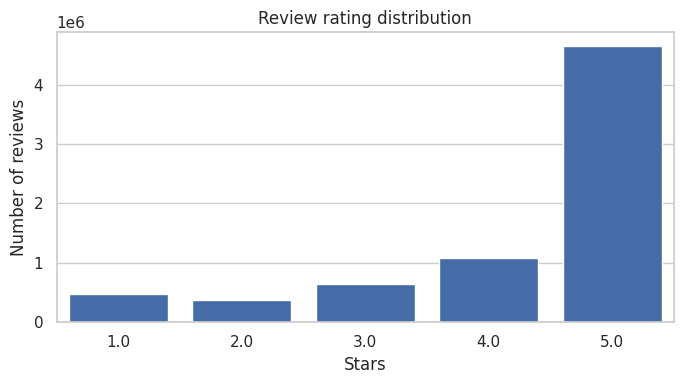

In [ ]:
sns.set_theme(style="whitegrid")

rating_pd = rating_counts.toPandas()
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=rating_pd, x="rating", y="count", color="#3569b7", ax=ax)
ax.set(title="Review rating distribution", xlabel="Stars", ylabel="Number of reviews")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "rating_distribution.png", dpi=200)
plt.show()

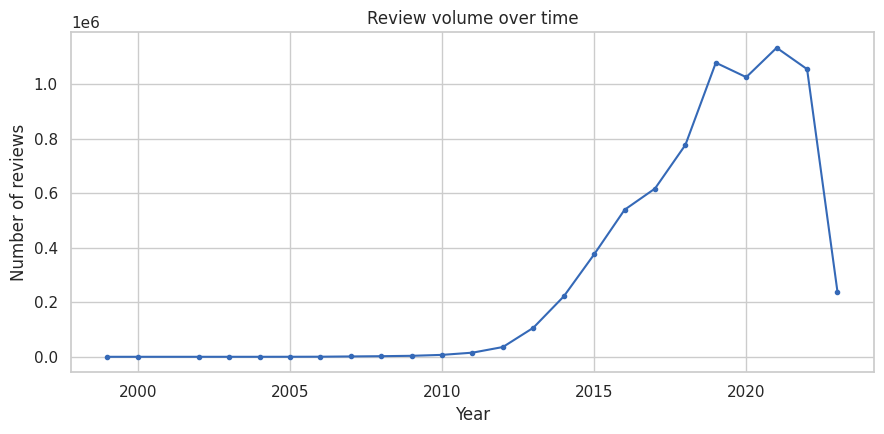

In [ ]:
yearly_pd = yearly.toPandas()
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(yearly_pd["review_year"], yearly_pd["reviews"], color="#3569b7", marker="o", ms=3)
ax1.set(title="Review volume over time", xlabel="Year", ylabel="Number of reviews")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "review_volume_by_year.png", dpi=200)
plt.show()


In [ ]:
rating_profile = (
    reviews.groupBy("rating")
    .agg(
        F.count("*").alias("reviews"),
        F.avg("text_length").alias("mean_text_length"),
        F.expr("percentile_approx(text_length, 0.5)").alias("median_text_length"),
        F.avg("helpful_vote").alias("mean_helpful_votes"),
        F.avg(F.col("verified_purchase").cast("double")).alias("verified_share"),
    )
    .orderBy("rating")
)

verified_ratings = (
    reviews.groupBy("verified_purchase", "rating")
    .count()
    .orderBy("verified_purchase", "rating")
)

product_concentration = (
    reviews.groupBy("parent_asin").count()
    .agg(
        F.count("*").alias("distinct_products"),
        F.max("count").alias("largest_product_reviews"),
        F.expr("percentile_approx(count, 0.5)").alias("median_reviews_per_product"),
        F.expr("percentile_approx(count, 0.99)").alias("p99_reviews_per_product"),
    )
)

rating_profile.show(truncate=False)
verified_ratings.show(truncate=False)
product_concentration.show(truncate=False)

+------+-------+------------------+------------------+------------------+------------------+
|rating|reviews|mean_text_length  |median_text_length|mean_helpful_votes|verified_share    |
+------+-------+------------------+------------------+------------------+------------------+
|1.0   |472381 |177.30914029141732|118               |1.32544069299993  |0.9348449662454671|
|2.0   |376802 |208.39648674900877|142               |0.9013354493872113|0.9299260619635776|
|3.0   |649147 |210.3709899298618 |139               |0.8709383236770716|0.9200797354066182|
|4.0   |1085590|215.89212317725844|135               |1.0155298040696763|0.895400657706869 |
|5.0   |4647623|151.4650659057329 |89                |0.8628423604926647|0.9309974152378538|
+------+-------+------------------+------------------+------------------+------------------+

+-----------------+------+-------+
|verified_purchase|rating|count  |
+-----------------+------+-------+
|false            |1.0   |30778  |
|false            |2.0

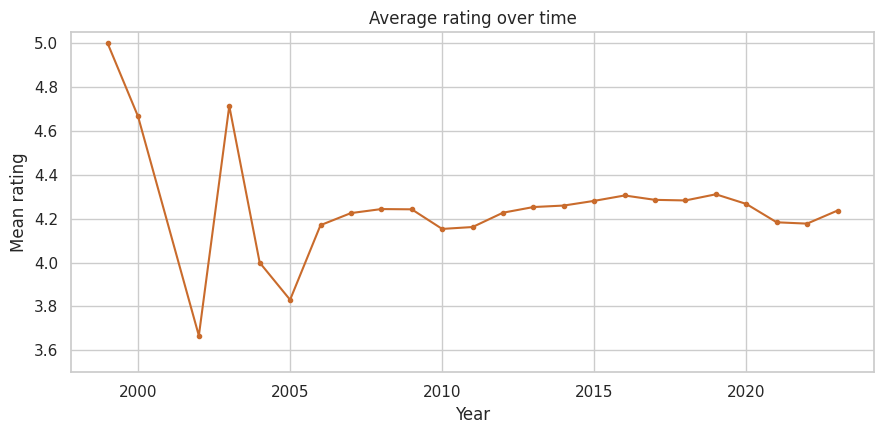

In [ ]:
yearly_pd = yearly.toPandas()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(yearly_pd["review_year"], yearly_pd["mean_rating"], color="#c96b2c", marker="o", ms=3)
ax.set(title="Average rating over time", xlabel="Year", ylabel="Mean rating", ylim=(3.5, 5.05))
fig.tight_layout()
fig.savefig(FIGURE_DIR / "mean_rating_by_year.png", dpi=200)
plt.show()

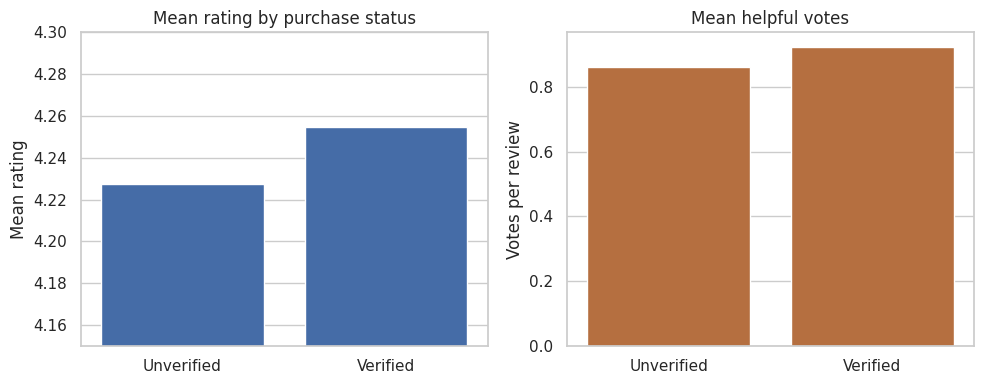

In [ ]:
verified_pd = verified.toPandas().sort_values("verified_purchase")
verified_pd["purchase_status"] = verified_pd["verified_purchase"].map({True: "Verified", False: "Unverified"})
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(data=verified_pd, x="purchase_status", y="mean_rating", color="#3569b7", ax=axes[0])
axes[0].set(title="Mean rating by purchase status", xlabel="", ylabel="Mean rating", ylim=(4.15, 4.30))
sns.barplot(data=verified_pd, x="purchase_status", y="mean_helpful_votes", color="#c96b2c", ax=axes[1])
axes[1].set(title="Mean helpful votes", xlabel="", ylabel="Votes per review")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "verified_purchase_comparison.png", dpi=200)
plt.show()

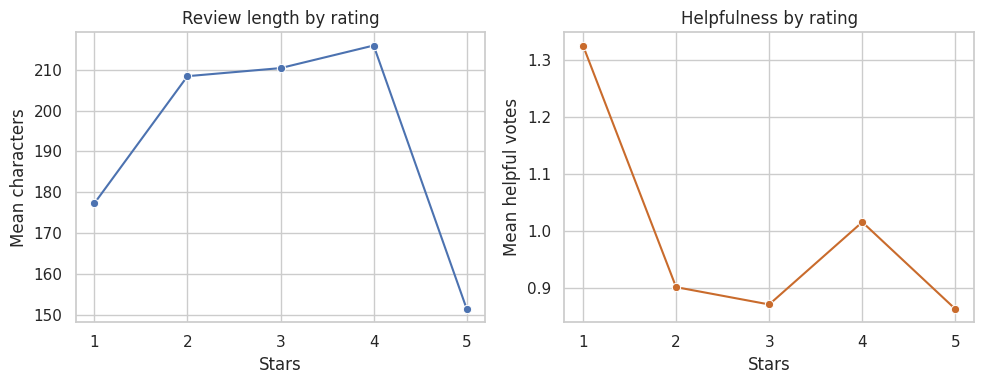

In [ ]:
profile_pd = rating_profile.toPandas()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.lineplot(data=profile_pd, x="rating", y="mean_text_length", marker="o", ax=axes[0])
axes[0].set(title="Review length by rating", xlabel="Stars", ylabel="Mean characters")
sns.lineplot(data=profile_pd, x="rating", y="mean_helpful_votes", marker="o", color="#c96b2c", ax=axes[1])
axes[1].set(title="Helpfulness by rating", xlabel="Stars", ylabel="Mean helpful votes")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "rating_length_helpfulness.png", dpi=200)
plt.show()

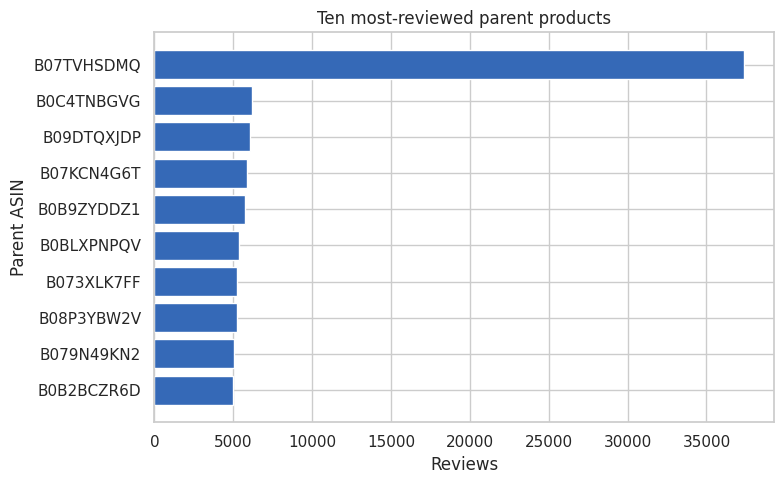

In [ ]:
top_pd = top_products.toPandas().head(10).sort_values("reviews")
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_pd["parent_asin"], top_pd["reviews"], color="#3569b7")
ax.set(title="Ten most-reviewed parent products", xlabel="Reviews", ylabel="Parent ASIN")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "top_products.png", dpi=200)
plt.show()

## Dataset-specific evidence for the 7 Vs

The table below creates an evidence framework. Replace no values manually: use the executed measurements and interpret them in the report.

| V | Dataset-specific evidence | Why it matters |
|---|---|---|
| Volume | Hosted raw-file bytes, working bytes, processing bytes, and Spark row count measured above | Requires distributed storage/processing and sampling decisions |
| Velocity | Reviews span many years and arrive as user-generated events; yearly counts quantify changes | Temporal drift means older patterns may not reflect current behaviour |
| Variety | Numeric ratings/votes, text, Boolean verification, arrays/images, IDs, and timestamps | Mixed structures require schema management and different analyses |
| Veracity | Nulls, potential duplicates, invalid values, extremes, and pseudonymous self-reports measured above | Quality problems can bias ratings, sentiment, and product comparisons |
| Value | Rating, demand, verification, and helpfulness patterns can support merchandising and customer-experience decisions | Converts processing into stakeholder-relevant evidence |
| Variability | Review volume, average rating, text length, and helpfulness differ over time and products | Aggregates can conceal seasonal or product-level heterogeneity |
| Visualization | Rating and temporal charts compress millions of records into interpretable patterns | Makes large-scale findings accessible while retaining accurate scales |


In [ ]:
evidence = {
    "volume": {**scale, "processing_rows": row_count, "columns": column_count},
    "velocity": {
        "earliest_review": str(quality["earliest_review"]),
        "latest_review": str(quality["latest_review"]),
        "years_observed": int(yearly.count()),
    },
    "variety": {"columns": reviews.columns, "schema": reviews.schema.simpleString()},
    "veracity": quality,
    "limitations": [
        "Reviews are voluntary and are not representative of all purchasers or users.",
        "Pseudonymous identifiers and product-page merging complicate duplicate detection.",
        "Ratings and helpful votes can be influenced by platform design, selection effects, or manipulation.",
        "A 3 GiB line-safe prefix may differ temporally or compositionally from the full category file.",
    ],
}
(OUTPUT_DIR / "part1_evidence.json").write_text(json.dumps(evidence, default=str, indent=2), encoding="utf-8")
print(json.dumps(evidence, default=str, indent=2)[:12000])


{
  "volume": {
    "raw_dataset_definition": "Amazon Reviews 2023 - Clothing, Shoes and Jewelry raw reviews",
    "hosted_file_bytes": 27810080533,
    "hosted_file_GB_decimal": 27.81,
    "displayed_source_size_GB": 27.8,
    "retrieved_utc": "2026-09-02T22:02:04.431848+00:00",
    "working_file_bytes": 27810080533,
    "working_file_GB_decimal": 27.81,
    "processing_file_bytes": 3221225482,
    "processing_file_GB_decimal": 3.221,
    "processing_rows": 7231543,
    "columns": 14
  },
  "velocity": {
    "earliest_review": "1999-12-01 01:41:03",
    "latest_review": "2023-03-25 20:39:13",
    "years_observed": 24
  },
  "variety": {
    "columns": [
      "asin",
      "helpful_vote",
      "images",
      "parent_asin",
      "rating",
      "text",
      "timestamp",
      "title",
      "user_id",
      "verified_purchase",
      "review_time",
      "review_year",
      "text_length",
      "title_length"
    ],
    "schema": "struct<asin:string,helpful_vote:bigint,images:arra

## Key findings, interpretation, and cautions

### Data quality
- No fields were represented as Spark nulls, but **495 records contained empty review text**. These are structurally present values and should not be described as fully complete text.
- The duplicate-key rule identified **23,544 potential duplicate rows (0.3256%)**. They were flagged rather than automatically removed because product variants or merged listings can produce legitimate repetition.
- Review text is right-skewed: the median length is **104 characters**, the mean is **171.1**, and 18 reviews exceed 10,000 characters.
- Helpful votes are highly right-skewed: the median and 75th percentile are zero, while the maximum is **41,199**. Mean helpful-vote comparisons can therefore be influenced by a small number of unusually popular reviews.

### EDA interpretation
- Five-star reviews account for **4,647,623 of 7,231,543 records (64.3%)**, demonstrating strong rating imbalance. Average ratings should therefore not be interpreted as a balanced view of positive and negative experiences.
- Review volume increased substantially after 2013 and reached its highest observed annual count in **2021 (1,133,095 reviews)**. The lower 2023 count is not directly comparable because the processed data ends on 25 March 2023.
- Mean ratings for the earliest years are unstable because those years contain very few reviews; for example, 1999 contains one observation and 2000 contains three. Trend interpretation should focus mainly on years with substantial counts.
- Verified reviews average **4.255 stars**, compared with **4.228** for unverified reviews—a small difference of about **0.027 stars**. The verified-purchase chart uses a narrowed y-axis to display this difference, so its visual size should not be mistaken for a large practical effect.
- Three- and four-star reviews are longer on average than five-star reviews. Five-star reviews have a mean length of **151.5 characters** and a median of **89**, suggesting that the most positive feedback is often more concise.
- Product activity is highly uneven: the processing data contains **1,836,721 parent products**, the median product has one review, the 99th percentile has 48, and the largest product has 37,409. A small number of products therefore account for unusually large review volumes.

### Scope and reproducibility
These findings describe the processed **3.221 GB sequential prefix**, not necessarily the entire 27.810 GB category file. The prefix may differ from the full dataset in product or temporal composition, reviews are voluntary rather than representative of all purchasers, and ratings or helpful votes may be affected by selection effects, platform design, or manipulation.

The notebook stores data under **/content/mit805_part1**, which is temporary Colab storage. A reset runtime requires the data to be downloaded and processed again.